# 08 — Propulsion Visualization

Verify propulsion duct sizing, clearance, aerodynamic performance, and 3D geometry.  
The duct is sized from first principles (scoop lip intake, Seddon S-duct, actuator disk).

Prerequisite: `output/best_x_v2.npy` from notebook 05.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from src.parameterization.design_variables import BWBParams, params_from_vector
from src.parameterization.bwb_aircraft import (
    build_body_kulfan_at_station, build_kulfan_airfoil_at_station,
)
from src.propulsion.edf_model import EDF_70MM
from src.propulsion.duct_geometry import (
    DuctSpine,
    size_and_place_duct, validate_duct_clearance,
    min_effective_clearance_mm, compute_duct_centerline,
    duct_cross_section, compute_duct_structure_mass,
    build_intake_geometry, build_sduct_geometry,
    build_edf_housing, build_exhaust_geometry,
    _body_surface_z, _build_body_surface_cache,
)
from src.propulsion.duct_aero import compute_duct_aero, print_duct_aero_summary
from src.config import load_all, load_config, duct_from_config, duct_aero_from_config
from src.visualization.style import COLORS

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})
%load_ext autoreload
%autoreload 2

## 1. Sizing & Placement Report

Physics-based duct sizing: scoop lip intake from capture ratio, S-duct from Seddon offset/L constraint, fan placement maximizes clearance.

In [2]:
best_x = np.load('../output/best_x_v2.npy')
params = params_from_vector(best_x)

cfg = load_config()
duct_cfg = duct_from_config(cfg)
aero_cfg = duct_aero_from_config(cfg)

placement = size_and_place_duct(params, EDF_70MM, config=duct_cfg)
centerline = compute_duct_centerline(placement, n_pts=200)

body_chord = params.body_root_chord
bw = params.body_halfwidth
bc = body_chord
duct_hw = placement.duct_od / 2.0
duct_mass = compute_duct_structure_mass(placement, config=duct_cfg)

fan_area = np.pi / 4 * EDF_70MM.fan_diameter ** 2
intake_area = placement.intake_width * placement.intake_depth
sduct_offset = abs((placement.intake_z - placement.intake_depth) - placement.fan_z)
sduct_length = placement.fan_x - (placement.intake_x + placement.intake_length)

# Thrust direction verification
spine = DuctSpine(placement)
nozzle_angle = spine.exhaust_angle_physical_deg()

print('=== Duct Sizing Report ===')
print(f'  Body chord      : {bc*1000:.0f} mm')
print(f'  Body halfwidth  : {bw*1000:.0f} mm')
print(f'  Body twist      : {params.body_twist:.1f} deg')
print()
print(f'  Intake x/c      : {placement.intake_x_frac:.2f} ({placement.intake_x*1000:.0f} mm)')
print(f'  Intake W x D    : {placement.intake_width*1000:.0f} x {placement.intake_depth*1000:.0f} mm')
print(f'  Intake length   : {placement.intake_length*1000:.0f} mm')
print(f'  Capture ratio   : {intake_area/fan_area:.2f} (target {duct_cfg.intake_capture_ratio})')
print()
print(f'  Fan x/c         : {placement.fan_x_frac:.2f} ({placement.fan_x*1000:.0f} mm)')
print(f'  Fan z           : {placement.fan_z*1000:.1f} mm')
print(f'  Duct OD         : {placement.duct_od*1000:.0f} mm')
print()
print(f'  S-duct offset   : {sduct_offset*1000:.1f} mm')
print(f'  S-duct length   : {sduct_length*1000:.0f} mm')
if sduct_length > 0:
    print(f'  S-duct O/L      : {sduct_offset/sduct_length:.2f} (max {duct_cfg.max_offset_length_ratio})')
print()
print(f'  Exhaust x/c     : {placement.exhaust_x_frac:.2f}')
print(f'  Exit W x H      : {placement.exhaust_width*1000:.0f} x {placement.exhaust_height*1000:.1f} mm')
print(f'  Nozzle A ratio  : {duct_cfg.nozzle_area_ratio:.2f}')
print()
print(f'  Nozzle exit angle (physical) : {nozzle_angle:.2f} deg (0 = horizontal)')
print(f'  Duct mass       : {duct_mass*1000:.0f} g')

=== Duct Sizing Report ===
  Body chord      : 462 mm
  Body halfwidth  : 80 mm
  Body twist      : 3.9 deg

  Intake x/c      : 0.05 (23 mm)
  Intake W x D    : 128 x 38 mm
  Intake length   : 46 mm
  Capture ratio   : 1.25 (target 1.25)

  Fan x/c         : 0.35 (161 mm)
  Fan z           : 16.4 mm
  Duct OD         : 78 mm

  S-duct offset   : 23.5 mm
  S-duct length   : 91 mm
  S-duct O/L      : 0.26 (max 0.25)

  Exhaust x/c     : 0.93
  Exit W x H      : 70 x 49.5 mm
  Nozzle A ratio  : 0.90

  Nozzle exit angle (physical) : -0.13 deg (0 = horizontal)
  Duct mass       : 224 g


## 2. Clearance Validation

Check that the duct fits within the body OML at every axial station.

In [3]:
# Validate clearance (min 5mm margin)
all_ok, clr_results = validate_duct_clearance(placement, params, min_clearance_mm=5.0)

# Print summary table at key stations
print("Station    x/c    CL_z    Duct_hh  OML_up  OML_lo  Clr_top  Clr_bot  Status")
print("-" * 82)
step = max(1, len(clr_results) // 10)
for r in clr_results[::step]:
    status = "OK" if r.is_ok else "** NOK **"
    line = f"  {r.x_frac:5.2f}   {r.centerline_z_mm:+6.1f}   {r.duct_half_h_mm:5.1f}   "
    line += f"{r.body_z_upper_mm:+6.1f}  {r.body_z_lower_mm:+6.1f}  "
    line += f"{r.clearance_top_mm:+6.1f}  {r.clearance_bot_mm:+6.1f}   {status}"
    print(line)

min_top = min(r.clearance_top_mm for r in clr_results)
min_bot = min(r.clearance_bot_mm for r in clr_results)
print(f"Min clearance -- top: {min_top:.1f} mm, bot: {min_bot:.1f} mm")

if all_ok:
    print("Overall: PASS (all stations >= 5mm margin)")
else:
    violations = [r for r in clr_results if not r.is_ok]
    print(f"Overall: WARNING -- {len(violations)} station(s) below 5mm threshold")
    for v in violations[:5]:
        print(f"  x/c={v.x_frac:.3f}  top={v.clearance_top_mm:+.1f}mm  bot={v.clearance_bot_mm:+.1f}mm")
    if min_top < -1.0 or min_bot < -1.0:
        print("CRITICAL: Duct penetrates body envelope")
    else:
        print("Note: minor violations, adjustable via duct centerline offset")


Station    x/c    CL_z    Duct_hh  OML_up  OML_lo  Clr_top  Clr_bot  Status
----------------------------------------------------------------------------------
   0.05    +30.4    18.8    +30.4   -18.9   -18.8   +30.5   ** NOK **
   0.14    +24.8    18.8    +46.0   -26.2    +2.4   +32.3   ** NOK **
   0.23    +19.6    29.8    +51.0   -29.6    +1.6   +19.4   ** NOK **
   0.32    +16.6    40.2    +51.9   -29.6    -4.9    +6.0   ** NOK **
   0.41    +15.8    40.2    +50.8   -26.4    -5.2    +2.0   ** NOK **
   0.50    +13.5    39.9    +47.8   -21.2    -5.6    -5.2   ** NOK **
   0.59    +10.4    37.4    +42.2   -15.2    -5.6   -11.7   ** NOK **
   0.68     +7.3    33.2    +34.2    -9.5    -6.3   -16.3   ** NOK **
   0.77     +4.9    28.7    +24.8    -4.6    -8.8   -19.3   ** NOK **
   0.86     +3.9    25.6    +15.8    -0.7   -13.6   -21.0   ** NOK **
Min clearance -- top: -20.7 mm, bot: -21.1 mm
Overall: WARNING -- 50 station(s) below 5mm threshold
  x/c=0.050  top=-18.8mm  bot=+30.5mm
  x

## 3. Longitudinal Integration (XZ plane, y=0)

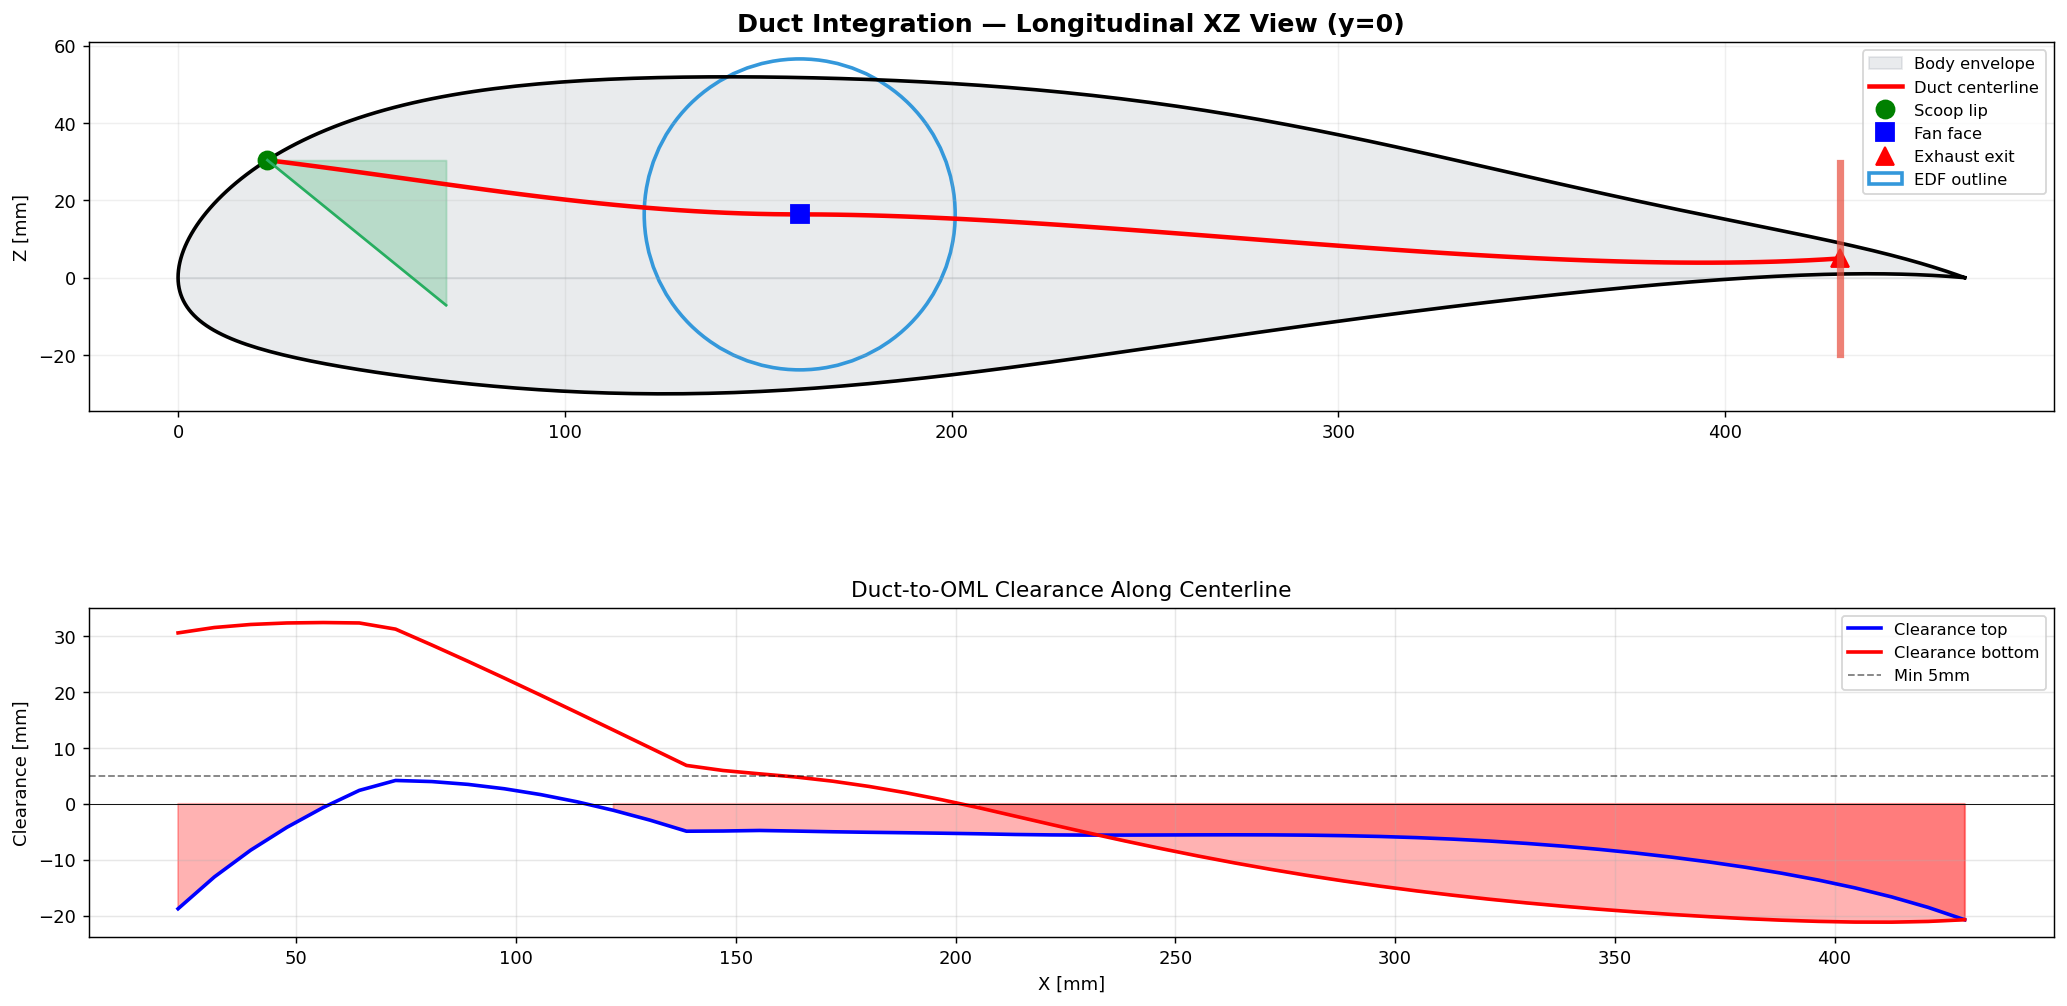

In [4]:
bc = body_chord  # shorthand
# Body airfoil outline
af = build_body_kulfan_at_station(params, 0.0).to_airfoil()
af_x = af.coordinates[:, 0] * bc * 1000
af_z = af.coordinates[:, 1] * bc * 1000

# Duct centerline
centerline = compute_duct_centerline(placement, n_pts=100)

# Clearance envelope from validation results
clr_x = [r.x_mm for r in clr_results]
clr_top = [r.clearance_top_mm for r in clr_results]
clr_bot = [r.clearance_bot_mm for r in clr_results]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), height_ratios=[3, 1])

# --- Top: XZ integration view ---
ax1.fill_between(af_x, af_z, alpha=0.1, color=COLORS['primary'], label='Body envelope')
ax1.plot(af_x, af_z, 'k-', linewidth=2)

# Duct centerline
ax1.plot(centerline[:, 0]*1000, centerline[:, 2]*1000,
         'r-', linewidth=2.5, label='Duct centerline')

# Key stations
ax1.plot(placement.intake_x*1000, placement.intake_z*1000,
         'go', markersize=10, label='Scoop lip')
ax1.plot(placement.fan_x*1000, placement.fan_z*1000,
         'bs', markersize=10, label='Fan face')
ax1.plot(placement.exhaust_x*1000, placement.exhaust_z*1000,
         'r^', markersize=10, label='Exhaust exit')

# EDF circle (structural OD for consistency with clearance envelope)
fan_r = (placement.duct_od / 2 + placement.duct_wall_thickness) * 1000
fan_circle = Circle((placement.fan_x*1000, placement.fan_z*1000), fan_r,
                     fill=False, color=COLORS['aileron'], linewidth=2, label='EDF outline')
ax1.add_patch(fan_circle)

# Intake scoop — linear descent (matches duct_geometry.py)
ramp_x = np.linspace(0, placement.intake_length*1000, 30)
ramp_depth = placement.intake_depth*1000 * (ramp_x / (placement.intake_length*1000))
ix_mm = placement.intake_x * 1000
iz_mm = placement.intake_z * 1000
ax1.fill_between(ix_mm + ramp_x, iz_mm, iz_mm - ramp_depth,
                 alpha=0.25, color=COLORS['feasible'])
ax1.plot(ix_mm + ramp_x, iz_mm - ramp_depth, '-', color=COLORS['feasible'], linewidth=1.5)

# Exhaust slot
ex_mm = placement.exhaust_x * 1000
ez_mm = placement.exhaust_z * 1000
eh_mm = placement.exhaust_height / 2 * 1000
ax1.plot([ex_mm, ex_mm], [ez_mm-eh_mm, ez_mm+eh_mm],
         '-', color=COLORS['infeasible'], linewidth=4, alpha=0.7)

ax1.set_ylabel('Z [mm]')
ax1.set_title('Duct Integration — Longitudinal XZ View (y=0)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.2)

# --- Bottom: Clearance diagram ---
ax2.plot(clr_x, clr_top, 'b-', linewidth=2, label='Clearance top')
ax2.plot(clr_x, clr_bot, 'r-', linewidth=2, label='Clearance bottom')
ax2.axhline(5.0, color='k', linestyle='--', linewidth=1, alpha=0.5, label='Min 5mm')
ax2.axhline(0, color='k', linewidth=0.5)
ax2.fill_between(clr_x, clr_top, 0, where=[t < 0 for t in clr_top],
                 alpha=0.3, color='red')
ax2.fill_between(clr_x, clr_bot, 0, where=[b < 0 for b in clr_bot],
                 alpha=0.3, color='red')
ax2.set_xlabel('X [mm]')
ax2.set_ylabel('Clearance [mm]')
ax2.set_title('Duct-to-OML Clearance Along Centerline')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/integration_xz_clearance.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Cross-Sections & Transverse Cuts

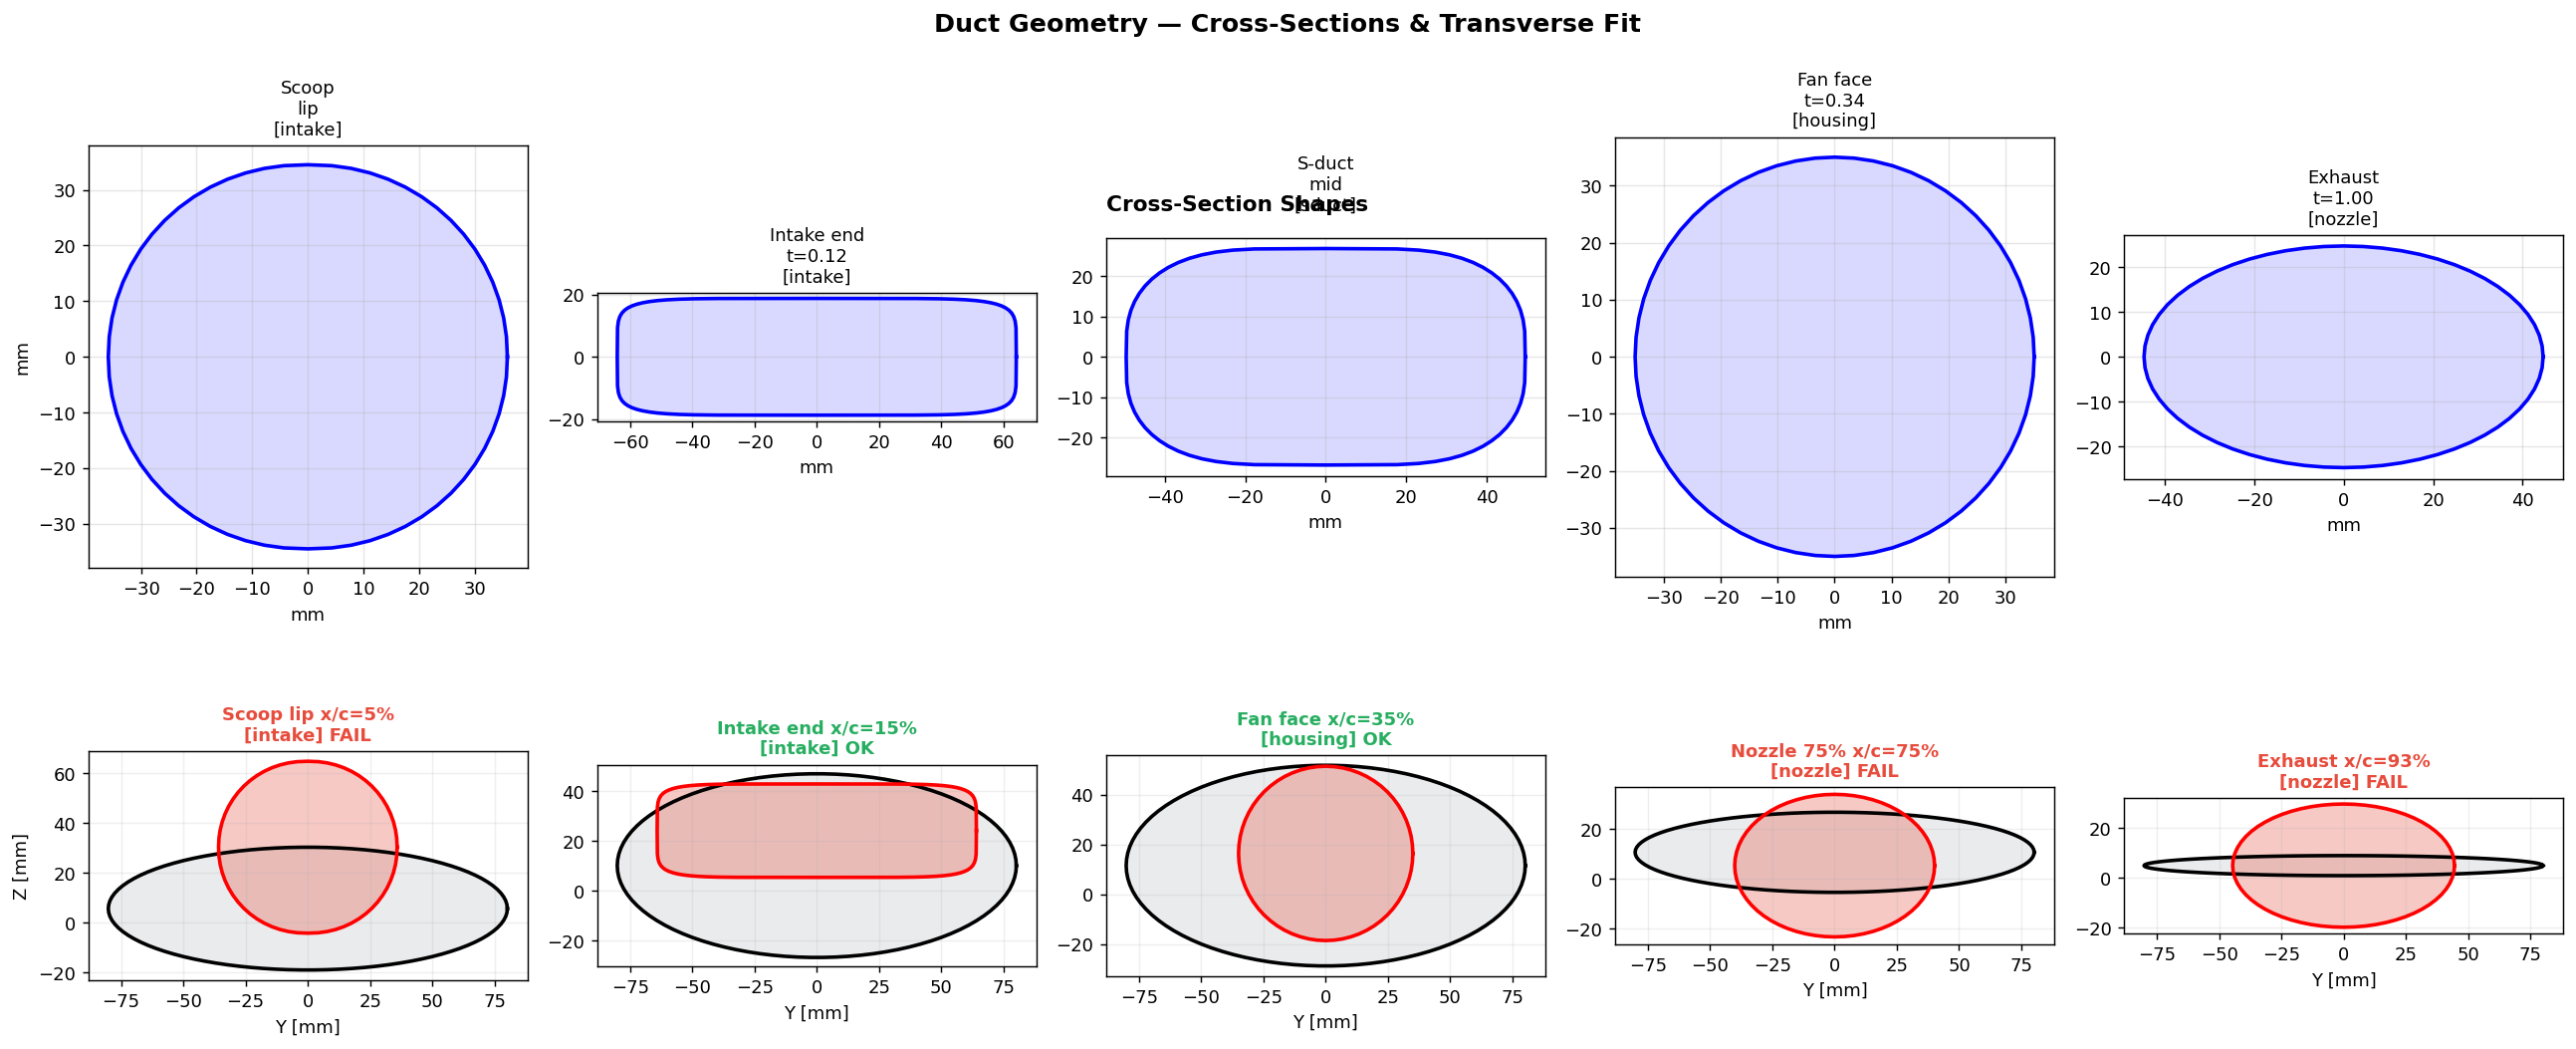

In [5]:
from src.propulsion.duct_geometry import _body_surface_z, _build_body_surface_cache
_bsc = _build_body_surface_cache(params)

spine = DuctSpine(placement)

fig, axes = plt.subplots(2, 5, figsize=(20, 9))

# Row 1: Cross-section shapes at segment boundaries
stations = [0.0, spine.t_ramp_end,
            (spine.t_ramp_end + spine.t_housing_start) / 2,
            spine.t_fan_face, 1.0]
names = ['Scoop\nlip', f'Intake end\nt={spine.t_ramp_end:.2f}',
         'S-duct\nmid', f'Fan face\nt={spine.t_fan_face:.2f}',
         f'Exhaust\nt=1.00']

for ax, t, name in zip(axes[0], stations, names):
    cs = duct_cross_section(t, placement, n_pts=64)
    cs_closed = np.vstack([cs, cs[0]])
    ax.plot(cs_closed[:, 0]*1000, cs_closed[:, 1]*1000, 'b-', linewidth=2)
    ax.fill(cs_closed[:, 0]*1000, cs_closed[:, 1]*1000, alpha=0.15, color='blue')
    seg = spine.segment_at(t)
    ax.set_title(f'{name}\n[{seg}]', fontsize=10)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('mm')
    if t == 0.0:
        ax.set_ylabel('mm')

# Row 2: Transverse body-vs-duct cuts at physical positions
cs_stations = [
    (placement.intake_x_frac, spine.t_at_x(placement.intake_x), 'Scoop lip'),
    ((placement.intake_x + placement.intake_length) / bc, spine.t_ramp_end, 'Intake end'),
    (placement.fan_x_frac, spine.t_fan_face, 'Fan face'),
    (0.75, spine.t_at_x(0.75 * bc), 'Nozzle 75%'),
    (placement.exhaust_x_frac, 1.0, 'Exhaust'),
]

cl = compute_duct_centerline(placement, n_pts=100)

for ax, (x_frac, t_cs, name) in zip(axes[1], cs_stations):
    z_up, z_cam, z_lo = _body_surface_z(x_frac, params, _cache=_bsc)
    # Body surface from Kulfan CST cache
    z_up_mm = z_up * bc * 1000
    z_lo_mm = z_lo * bc * 1000
    z_cam_mm = z_cam * bc * 1000
    body_hw_mm = params.body_halfwidth * 1000

    # Body cross-section (elliptical approximation)
    th_up = np.linspace(0, np.pi, 50)
    th_lo = np.linspace(np.pi, 2*np.pi, 50)
    b_up = z_up_mm - z_cam_mm
    b_lo = z_cam_mm - z_lo_mm
    y_body = np.concatenate([body_hw_mm * np.cos(th_up), body_hw_mm * np.cos(th_lo)])
    z_body = np.concatenate([z_cam_mm + b_up * np.sin(th_up),
                             z_cam_mm + b_lo * np.sin(th_lo)])
    ax.fill(y_body, z_body, alpha=0.1, color=COLORS['primary'])
    ax.plot(y_body, z_body, 'k-', linewidth=2)

    # Duct cross-section at centerline z (using spine for consistent position)
    cs = duct_cross_section(t_cs, placement, n_pts=64)
    cs_closed = np.vstack([cs, cs[0]])
    pos = spine.position(t_cs)
    duct_cz = pos[2] * 1000
    ax.fill(cs_closed[:, 0]*1000, cs_closed[:, 1]*1000 + duct_cz,
            alpha=0.3, color=COLORS['infeasible'])
    ax.plot(cs_closed[:, 0]*1000, cs_closed[:, 1]*1000 + duct_cz,
            'r-', linewidth=2)

    # Check fit
    duct_top = duct_cz + cs[:, 1].max() * 1000
    duct_bot = duct_cz + cs[:, 1].min() * 1000
    ok = duct_top < z_up_mm and duct_bot > z_lo_mm
    color = COLORS['feasible'] if ok else COLORS['infeasible']
    seg = spine.segment_at(t_cs)
    ax.set_title(f'{name} x/c={x_frac:.0%}\n[{seg}] {"OK" if ok else "FAIL"}',
                 fontsize=10, color=color, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.set_xlabel('Y [mm]')
    if ax == axes[1][0]:
        ax.set_ylabel('Z [mm]')

axes[0][2].set_title('Cross-Section Shapes', fontsize=12, fontweight='bold', loc='left', pad=15)
fig.suptitle('Duct Geometry — Cross-Sections & Transverse Fit', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/integration_cross_sections.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Duct Aerodynamic Performance

  DUCT AERODYNAMIC PERFORMANCE
  Mass flow rate:       0.1971 kg/s
  Fan face velocity:    41.8 m/s

  Intake capture area:  64.4 cm²
  Fan face area:        38.5 cm²
  Exhaust exit area:    34.6 cm²
  Nozzle area ratio:    0.900

  Pressure recovery:
    Intake (NACA):      0.960
    S-duct:             0.992
    Nozzle:             0.960
    TOTAL:              0.914

  Exit velocity:        46.5 m/s
  Velocity ratio:       1.86
  S-duct offset/L:      0.257
  CD intake increment:  0.00104

  WARNINGS:
    - Intake area 48.1 cm² < required 64.4 cm² (mass flow deficit)


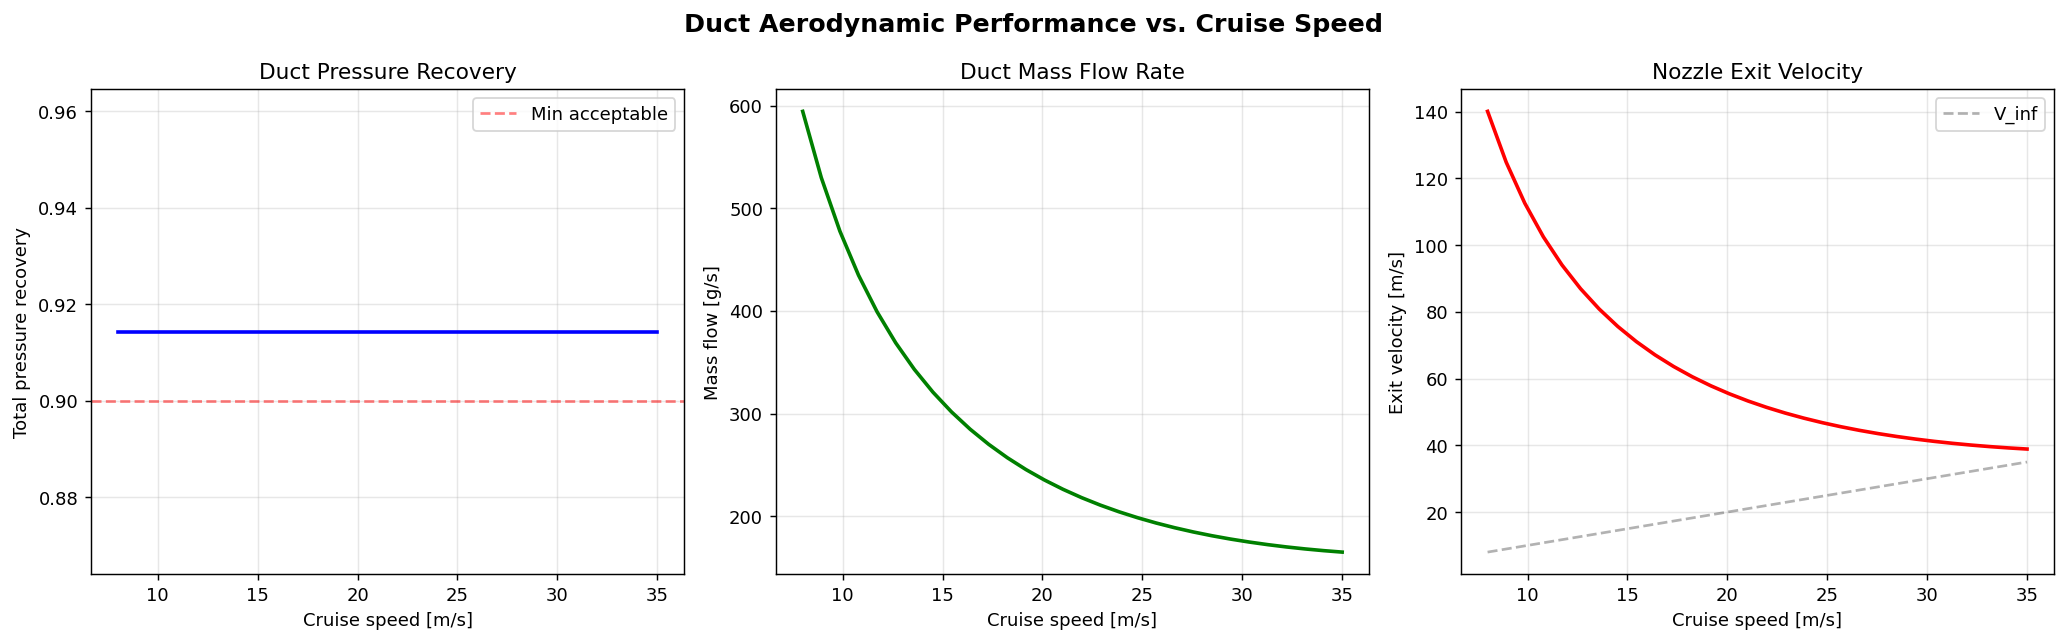

In [6]:
# Detailed summary at cruise speed
aero = compute_duct_aero(placement, EDF_70MM, params, velocity=25.0, config=aero_cfg)
print_duct_aero_summary(aero)

# Performance vs. cruise speed
velocities = np.linspace(8, 35, 30)
pr_totals, mass_flows, exit_vels = [], [], []
for v in velocities:
    r = compute_duct_aero(placement, EDF_70MM, params, velocity=v, config=aero_cfg)
    pr_totals.append(r.pr_total)
    mass_flows.append(r.mass_flow)
    exit_vels.append(r.exit_velocity)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

ax1.plot(velocities, pr_totals, 'b-', linewidth=2)
ax1.axhline(0.90, color='r', linestyle='--', alpha=0.5, label='Min acceptable')
ax1.set_xlabel('Cruise speed [m/s]')
ax1.set_ylabel('Total pressure recovery')
ax1.set_title('Duct Pressure Recovery')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(velocities, np.array(mass_flows)*1000, 'g-', linewidth=2)
ax2.set_xlabel('Cruise speed [m/s]')
ax2.set_ylabel('Mass flow [g/s]')
ax2.set_title('Duct Mass Flow Rate')
ax2.grid(True, alpha=0.3)

ax3.plot(velocities, exit_vels, 'r-', linewidth=2)
ax3.plot(velocities, velocities, 'k--', alpha=0.3, label='V_inf')
ax3.set_xlabel('Cruise speed [m/s]')
ax3.set_ylabel('Exit velocity [m/s]')
ax3.set_title('Nozzle Exit Velocity')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle('Duct Aerodynamic Performance vs. Cruise Speed',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. 3D Visualization

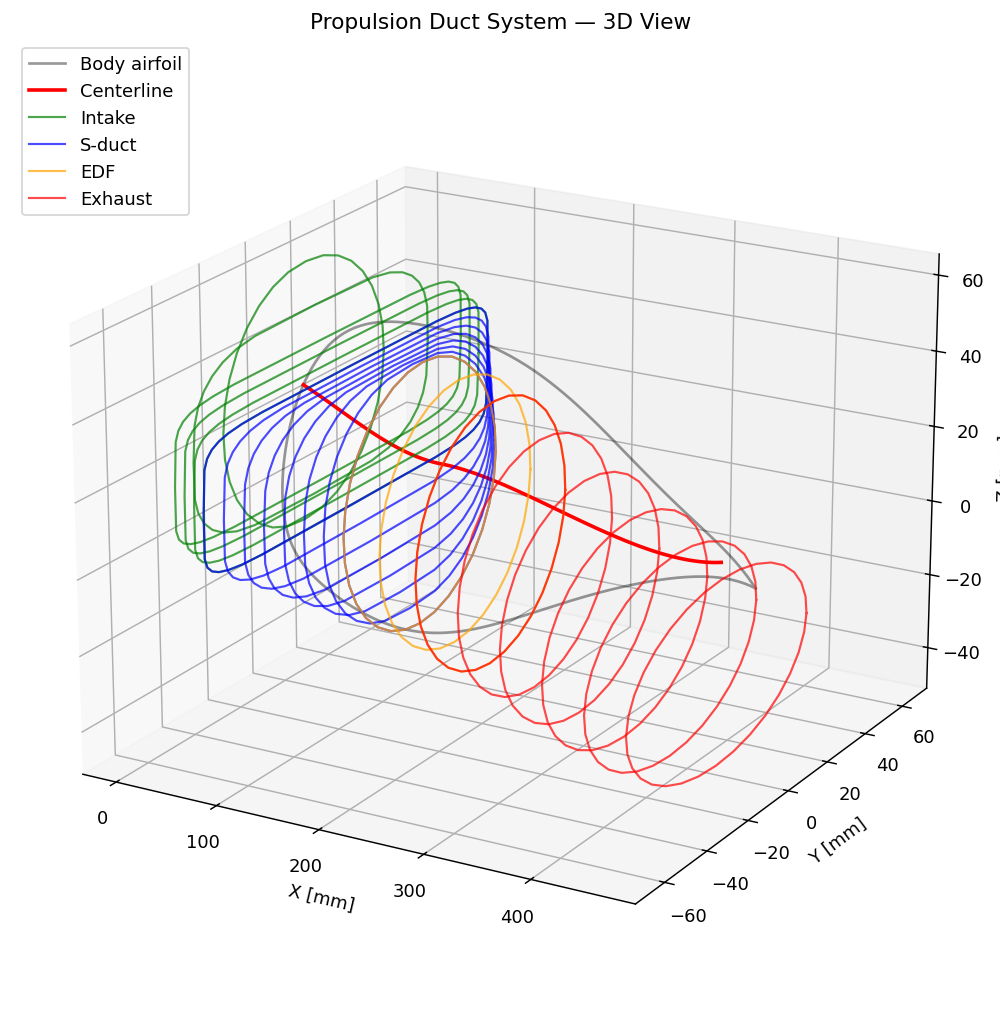

In [7]:
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')

# Body airfoil outline at y=0
ax.plot(af.coordinates[:, 0] * bc * 1000,
        np.zeros(len(af.coordinates)),
        af.coordinates[:, 1] * bc * 1000,
        'k-', linewidth=1.5, alpha=0.4, label='Body airfoil')

# Duct centerline
ax.plot(centerline[:, 0]*1000, centerline[:, 1]*1000,
        centerline[:, 2]*1000, 'r-', linewidth=2, label='Centerline')

# Component sections
colors = {'Intake': 'green', 'S-duct': 'blue', 'EDF': 'orange', 'Exhaust': 'red'}
components = [
    ('Intake', build_intake_geometry(placement, params, n_profile=32, n_axial=6)),
    ('S-duct', build_sduct_geometry(placement, params, EDF_70MM, n_stations=8, n_profile=32)),
    ('EDF', build_edf_housing(placement, EDF_70MM, n_profile=32, n_axial=3)),
    ('Exhaust', build_exhaust_geometry(placement, params, EDF_70MM, n_stations=6, n_profile=32)),
]

for name, sections in components:
    c = colors[name]
    for i, sec in enumerate(sections):
        sec_closed = np.vstack([sec, sec[0]])
        label = name if i == 0 else None
        ax.plot(sec_closed[:, 0]*1000, sec_closed[:, 1]*1000,
                sec_closed[:, 2]*1000, '-', color=c, linewidth=1.2,
                alpha=0.7, label=label)

ax.set_xlabel('X [mm]')
ax.set_ylabel('Y [mm]')
ax.set_zlabel('Z [mm]')
ax.set_title('Propulsion Duct System — 3D View')
ax.legend(loc='upper left')
ax.view_init(elev=20, azim=-60)
plt.tight_layout()
plt.show()

## 7. STL Export

In [ ]:
from src.visualization.export import export_aircraft_stl
from src.propulsion.duct_geometry import build_propulsion_mesh
from stl import mesh as stl_mesh

# 1) OML only (no duct)
oml_path = '../output/manta_oml.stl'
n_oml = export_aircraft_stl(params, oml_path, include_propulsion=False)
print(f'OML exported: {n_oml} triangles -> {oml_path}')

# 2) Duct only
duct_path = '../output/manta_duct.stl'
duct_tris = build_propulsion_mesh(params, EDF_70MM, n_profile=32)
duct_mesh = stl_mesh.Mesh(np.zeros(len(duct_tris), dtype=stl_mesh.Mesh.dtype))
for j, tri in enumerate(duct_tris):
    duct_mesh.vectors[j] = tri
duct_mesh.save(duct_path)
print(f'Duct exported: {len(duct_tris)} triangles -> {duct_path}')